# Set Up

## A. Library

Menginstall Library: (1) Pytorch dan (2) Transformer

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
%pip install transformers
%pip install umap-learn

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Mengimport Library

In [ ]:
import os
import torch
import logging
import warnings
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.patches as mpatches
import umap.umap_ as umap

d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## B. Device

Melakukan Set Up Device:<br>(1) Mendeteksi Hardware,<br>(2) Melakukan Konfigurasi Device yang Akan Digunakan Dalam Eksperimen ini,<br>(3) Memastikan Komputasi Berjalan di GPU

In [3]:
# =========================================================
# 1. SETUP LIBRARY & DEVICE
# =========================================================

print("-" * 50)
# Logika pendeteksian perangkat
# Jika CUDA (GPU NVIDIA) tersedia, gunakan 'cuda'. Jika tidak, pakai 'cpu'.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
    print(f"Versi CUDA: {torch.version.cuda}")
else:
    print("Peringatan: GPU tidak terdeteksi. Proses akan berjalan lambat di CPU.")
print("-" * 50)

os.environ["DISABLE_SAFETENSORS_CONVERSION"] = "1"

--------------------------------------------------
Device yang digunakan: cuda
Nama GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Versi CUDA: 12.4
--------------------------------------------------


## C. Model

### 1. Load Model IndoBERT (Versi IndoLEM)

Load Model IndoBERT Versi IndoLEM (Koto et al., 2020)

In [4]:
print("Melakukan Loading Model IndoBERT (IndoLEM):")
print("="*75)
indobert_name = "indolem/indobert-base-uncased"
tokenizer_indobert = AutoTokenizer.from_pretrained(indobert_name)
model_indobert = AutoModel.from_pretrained(indobert_name, output_hidden_states=True).to(device)
model_indobert.eval() # Set ke mode evaluasi agar setiap dijalankan tidak terjadi perubahan pada bobot model
print("Info: Model IndoBERT berhasil dimuat✅")
print("="*75)

Melakukan Loading Model IndoBERT (IndoLEM):


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15071.62it/s]
BertModel LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Info: Model IndoBERT berhasil dimuat✅


Note: Model yang Diload Menggunakan Model Evaluasi Dikarnakan Kita Hanya Ingin Mengekstrak Representasinya Saja Sehingga Komponen Dropout-nya Perlu untuk Dimatikan Agar Representasi yang Keluar dari Tiap Lapisan Tidak Akan Berubah-ubah Setiap Kali Dijalankan

### 2. Load Model XLM-R

In [5]:
print("Melakukan Loading Model XLM-R:")
print("="*75)
xlmr_name = "xlm-roberta-base"
tokenizer_xlmr = AutoTokenizer.from_pretrained(xlmr_name)
model_xlmr = AutoModel.from_pretrained(xlmr_name, output_hidden_states=True).to(device)
model_xlmr.eval() # Set ke mode evaluasi agar setiap dijalankan tidak terjadi perubahan pada bobot model
print("Info: Model XLM-R berhasil dimuat✅")
print("="*75)

Melakukan Loading Model XLM-R:


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10692.08it/s]
XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Info: Model XLM-R berhasil dimuat✅


Note: Model yang Diload Menggunakan Model Evaluasi Dikarnakan Kita Hanya Ingin Mengekstrak Representasinya Saja Sehingga Komponen Dropout-nya Perlu untuk Dimatikan Agar Representasi yang Keluar dari Tiap Lapisan Tidak Akan Berubah-ubah Setiap Kali Dijalankan

# Eksperimen

## A. Morfologi Afiksasi (Surface)

### 1. Load Dataset dan Encode Label

Encode label: Konfiks = 0, Prefiks = 1, Sufiks = 2, Tidak Berimbuhan = 3

In [6]:
# ============================================================
# TAHAP 1: LOAD DATASET MORFOLOGI AFIKSASI
# ============================================================

BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Morfologi_Afiksasi"

df_train_raw = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_train_morph.csv"))
df_dev_raw   = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_dev_morph.csv"))
df_test_raw  = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_test_morph.csv"))

COLS_X = ['sent_id', 'token_id', 'token']
COLS_Y = 'tipe_afiks'

df_train = df_train_raw[COLS_X + [COLS_Y]].copy()
df_dev   = df_dev_raw  [COLS_X + [COLS_Y]].copy()
df_test  = df_test_raw [COLS_X + [COLS_Y]].copy()

# Encode label
label_encoder = LabelEncoder()
label_encoder.fit(df_train[COLS_Y])

y_train = label_encoder.transform(df_train[COLS_Y])
y_dev   = label_encoder.transform(df_dev  [COLS_Y])
y_test  = label_encoder.transform(df_test [COLS_Y])

df_train['label_encoded'] = y_train
df_dev['label_encoded']   = y_dev
df_test['label_encoded']  = y_test

NUM_CLASSES = len(label_encoder.classes_)
NUM_LAYERS  = 13    # layer-0 (embedding) + layer 1–12 (transformer)
HIDDEN_SIZE = 768

print("=" * 55)
print("INFO DATASET MORFOLOGI AFIKSASI")
print("=" * 55)
print(f"Kolom X : {COLS_X}")
print(f"Kolom Y : {COLS_Y}")
print(f"Kelas   : {list(label_encoder.classes_)}")
print(f"Train   : {len(df_train):,} token")
print(f"Dev     : {len(df_dev):,} token")
print(f"Test    : {len(df_test):,} token")

INFO DATASET MORFOLOGI AFIKSASI
Kolom X : ['sent_id', 'token_id', 'token']
Kolom Y : tipe_afiks
Kelas   : ['Konfiks', 'Prefiks', 'Sufiks', 'Tidak Berimbuhan']
Train   : 82,963 token
Dev     : 10,676 token
Test    : 10,056 token


### 2. Ekstraksi Hidden States

Yang dilakukan:
1. Mengekstrak hidden states semua layer untuk setiap token

Input:
1. df: DataFrame dengan kolom [sent_id, token_id, token, tipe_afiks]
2. tokenizer, model : model HuggingFace yang sudah di-load

Output:
1. np.array shape (total_token, num_layer, hidden_size) | misal: (9232, 13, 768)
2. Layer 0     = embedding statis (non-contextual)
3. Layer 1–12  = transformer layers (contextual)

In [7]:
# ============================================================
# TAHAP 2: FUNGSI EKSTRAKSI HIDDEN STATES
# ============================================================

def extract_hidden_states(df, tokenizer, model, device, desc="Ekstraksi"):
    model.eval()
    all_hidden  = []
    all_labels  = []
    skipped_cnt = 0

    # Groupby sent_id, sort token berdasarkan token_id
    grouped = df.groupby('sent_id', sort=False)

    for sent_id, group in tqdm(grouped, desc=desc):
        group  = group.sort_values('token_id')
        tokens = group['token'].tolist()
        labels = group['label_encoded'].tolist()

        # Tokenisasi — is_split_into_words=True karena input sudah list kata
        # Satu kata bisa dipecah jadi beberapa subword oleh tokenizer
        encoding = tokenizer(
            tokens,
            is_split_into_words = True,
            return_tensors      = "pt",
            padding             = True,
            truncation          = True,
            max_length          = 512
        )

        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

        hidden_states = outputs.hidden_states

        # ── Mapping subword → token asli ──────────────────────────
        # word_ids() mengembalikan list index kata asli untuk tiap subword
        # Contoh: "membangun" → ["mem", "##bangun"]
        #   word_ids = [None, 0, 0, 0, 1, 1, 2, None]
        #              [CLS] [mem][##b][##u][tok1][tok2] [SEP]
        # Strategi: ambil subword PERTAMA sebagai representasi kata
        word_ids = encoding.word_ids(batch_index=0)

        first_subword_pos = {}
        for pos, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in first_subword_pos:
                first_subword_pos[word_idx] = pos

        for word_idx in range(len(tokens)):
            if word_idx not in first_subword_pos:
                skipped_cnt += 1
                continue

            pos = first_subword_pos[word_idx]

            token_repr = np.array([
                hidden_states[layer_idx][0, pos, :].cpu().numpy()
                for layer_idx in range(len(hidden_states))
            ])

            all_hidden.append(token_repr)
            all_labels.append(labels[word_idx])

    if skipped_cnt > 0:
        print(f"  ⚠ {skipped_cnt} token dilewati akibat truncation (max_length=512)")

    return np.array(all_hidden), np.array(all_labels) 

### 3. Eksekusi Ekstraksi: IndoBERT

Direktori Hidden States Morfologi Afiksasi:

In [8]:
SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi"
os.makedirs(SAVE_DIR, exist_ok=True)

Ekstraksi IndoBERT:

In [9]:
# ============================================================
# TAHAP 3: EKSTRAKSI FITUR (INDOBERT) & SIMPAN KE DISK
# ============================================================
# ⚠ Cell ini cukup dijalankan SEKALI.
#   Setelah file .npz tersimpan, langsung lompat ke Tahap 5.
# ============================================================

# ── IndoBERT ──────────────────────────────────────────────────────────────
print("=" * 60)
print("EKSTRAKSI HIDDEN STATES — IndoBERT")
print("=" * 60)

# [PERBAIKAN]: Tangkap X dan y dari fungsi ekstraksi
X_train_indobert, y_train_ib = extract_hidden_states(
    df_train, tokenizer_indobert, model_indobert, device, "IndoBERT | Train")
X_dev_indobert,   y_dev_ib   = extract_hidden_states(
    df_dev,   tokenizer_indobert, model_indobert, device, "IndoBERT | Dev  ")
X_test_indobert,  y_test_ib  = extract_hidden_states(
    df_test,  tokenizer_indobert, model_indobert, device, "IndoBERT | Test ")

print(f"\nShape → Train: {X_train_indobert.shape} | "
      f"Dev: {X_dev_indobert.shape} | Test: {X_test_indobert.shape}")

print("Menyimpan IndoBERT ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR, "indobert_morph.npz"),
    train   = X_train_indobert,
    dev     = X_dev_indobert,
    test    = X_test_indobert,
    y_train = y_train_ib,
    y_dev   = y_dev_ib,
    y_test  = y_test_ib
)
print(f"✅ Tersimpan → indobert_morph.npz")

del X_train_indobert, X_dev_indobert, X_test_indobert  # bebaskan RAM
print(f"   Lokasi: {SAVE_DIR}")

EKSTRAKSI HIDDEN STATES — IndoBERT


IndoBERT | Train: 100%|██████████| 4476/4476 [02:08<00:00, 34.84it/s]


  ⚠ 2 token dilewati akibat truncation (max_length=512)


IndoBERT | Dev  : 100%|██████████| 559/559 [00:17<00:00, 32.64it/s]
IndoBERT | Test : 100%|██████████| 557/557 [00:15<00:00, 35.32it/s]



Shape → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
Menyimpan IndoBERT ke disk...
✅ Tersimpan → indobert_morph.npz
   Lokasi: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi


### 4. Eksekusi Ekstraksi: XLM-R

In [10]:
# ============================================================
# TAHAP 4: EKSTRAKSI FITUR (XLM-R) & SIMPAN KE DISK
# ============================================================

print("\n" + "=" * 60)
print("EKSTRAKSI HIDDEN STATES — XLM-R")
print("=" * 60)

# Tangkap X dan y khusus untuk XLM-R
X_train_xlmr, y_train_xlmr = extract_hidden_states(
    df_train, tokenizer_xlmr, model_xlmr, device, "XLM-R   | Train")
X_dev_xlmr,   y_dev_xlmr   = extract_hidden_states(
    df_dev,   tokenizer_xlmr, model_xlmr, device, "XLM-R   | Dev  ")
X_test_xlmr,  y_test_xlmr  = extract_hidden_states(
    df_test,  tokenizer_xlmr, model_xlmr, device, "XLM-R   | Test ")

print(f"\nShape → Train: {X_train_xlmr.shape} | Dev: {X_dev_xlmr.shape} | Test: {X_test_xlmr.shape}")

print("Menyimpan XLM-R ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR, "xlmr_morph.npz"),
    train   = X_train_xlmr,
    dev     = X_dev_xlmr,
    test    = X_test_xlmr,
    y_train = y_train_xlmr,
    y_dev   = y_dev_xlmr,
    y_test  = y_test_xlmr
)
print(f"✅ Tersimpan → xlmr_morph.npz")
del X_train_xlmr, X_dev_xlmr, X_test_xlmr  # bebaskan RAM


EKSTRAKSI HIDDEN STATES — XLM-R


XLM-R   | Train: 100%|██████████| 4476/4476 [02:10<00:00, 34.32it/s]


  ⚠ 2 token dilewati akibat truncation (max_length=512)


XLM-R   | Dev  : 100%|██████████| 559/559 [00:16<00:00, 32.90it/s]
XLM-R   | Test : 100%|██████████| 557/557 [00:15<00:00, 34.93it/s]



Shape → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
Menyimpan XLM-R ke disk...
✅ Tersimpan → xlmr_morph.npz


### 5. Load Hasil Ekstraksi Hidden States

In [11]:
# ==========================
# TAHAP 5: LOAD DARI DISK  
# ==========================

SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi"

print("Memuat hidden states dari disk...")
data_indobert    = np.load(os.path.join(SAVE_DIR, "indobert_morph.npz"))
X_train_indobert = data_indobert['train']
X_dev_indobert   = data_indobert['dev']
X_test_indobert  = data_indobert['test']
y_train          = data_indobert['y_train']
y_dev            = data_indobert['y_dev']
y_test           = data_indobert['y_test']

data_xlmr    = np.load(os.path.join(SAVE_DIR, "xlmr_morph.npz"))
X_train_xlmr = data_xlmr['train']
X_dev_xlmr   = data_xlmr['dev']
X_test_xlmr  = data_xlmr['test']

print(f"✅ IndoBERT → Train: {X_train_indobert.shape} | "
      f"Dev: {X_dev_indobert.shape} | Test: {X_test_indobert.shape}")
print(f"✅ XLM-R    → Train: {X_train_xlmr.shape} | "
      f"Dev: {X_dev_xlmr.shape} | Test: {X_test_xlmr.shape}")

Memuat hidden states dari disk...
✅ IndoBERT → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
✅ XLM-R    → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)


### 6. Training Probing Classifier (Linear Classifier - Single Linear Layer)


TRAINING PROBING CLASSIFIER PER LAYER — MORFOLOGI AFIKSASI
Layer    IB Acc    IB P    IB R   IB F1 │ XLM Acc   XLM P   XLM R  XLM F1
-------------------------------------------------------------------------------------
L0       0.9738  0.9735  0.9738  0.9732 │  0.9403  0.9376  0.9403  0.9352
L1       0.9668  0.9661  0.9668  0.9663 │  0.9396  0.9368  0.9396  0.9342
L2       0.9565  0.9559  0.9565  0.9559 │  0.9483  0.9467  0.9483  0.9468
L3       0.9505  0.9500  0.9505  0.9500 │  0.9564  0.9557  0.9564  0.9560
L4       0.9528  0.9520  0.9528  0.9522 │  0.9604  0.9601  0.9604  0.9602
L5       0.9493  0.9486  0.9493  0.9488 │  0.9551  0.9535  0.9551  0.9534
L6       0.9457  0.9440  0.9457  0.9434 │  0.9506  0.9499  0.9506  0.9501
L7       0.9427  0.9404  0.9427  0.9408 │  0.9475  0.9459  0.9475  0.9460
L8       0.9346  0.9324  0.9346  0.9309 │  0.9444  0.9425  0.9444  0.9432
L9       0.9298  0.9271  0.9298  0.9281 │  0.9447  0.9442  0.9447  0.9443
L10      0.9215  0.9169  0.9215  0.9184 

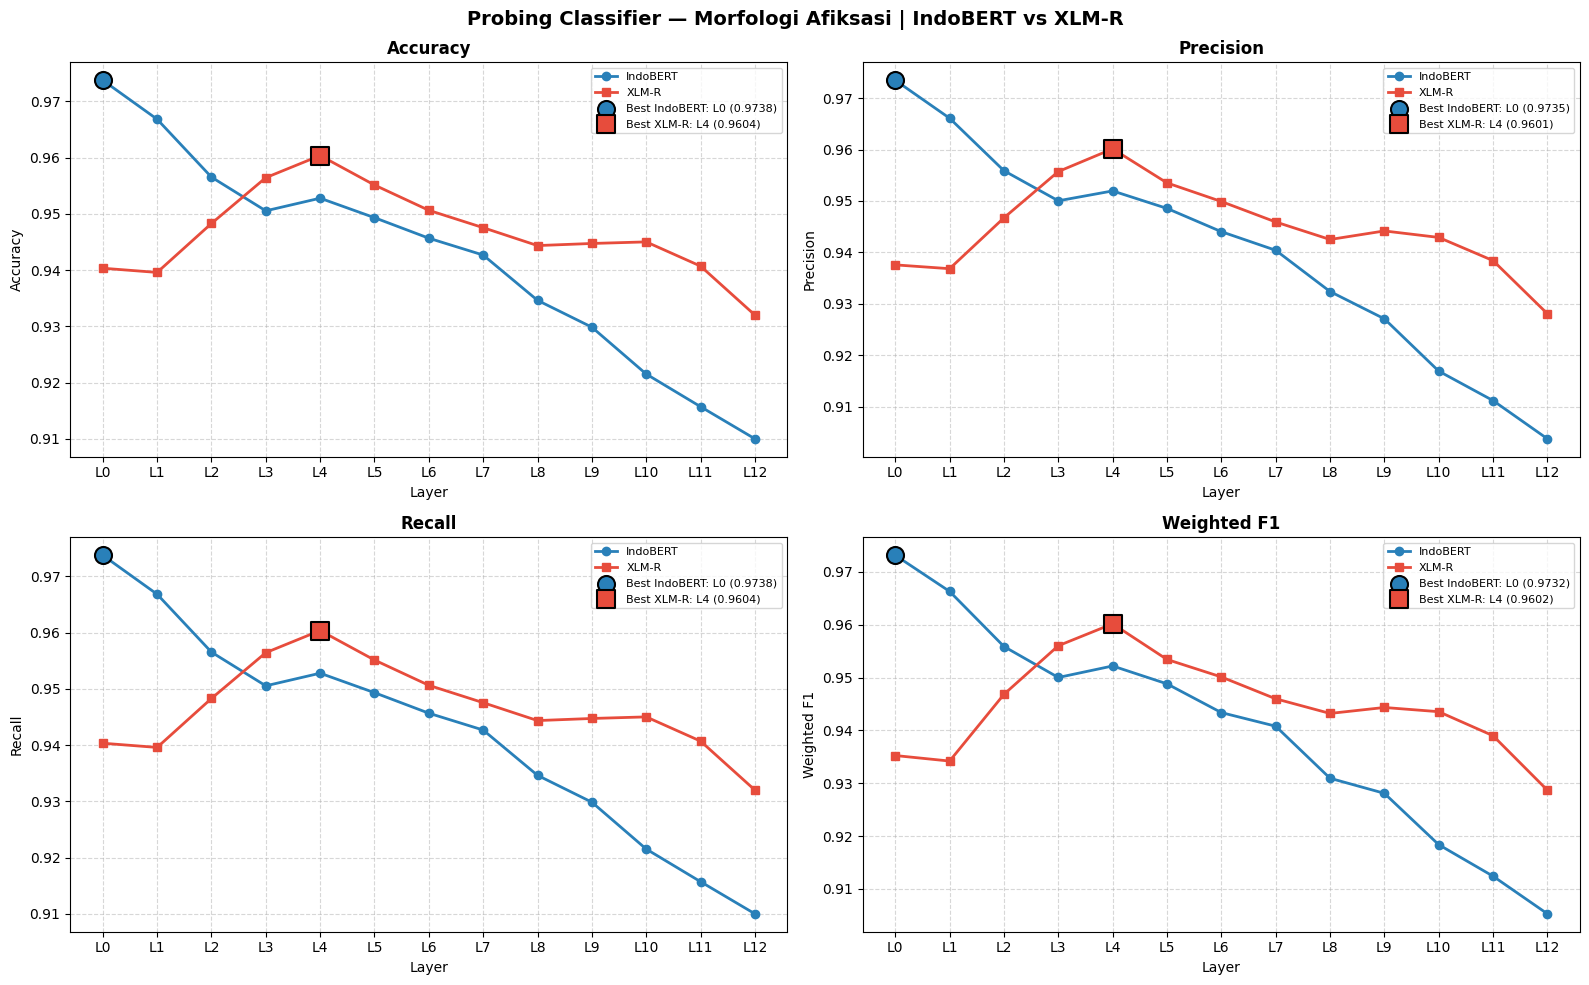

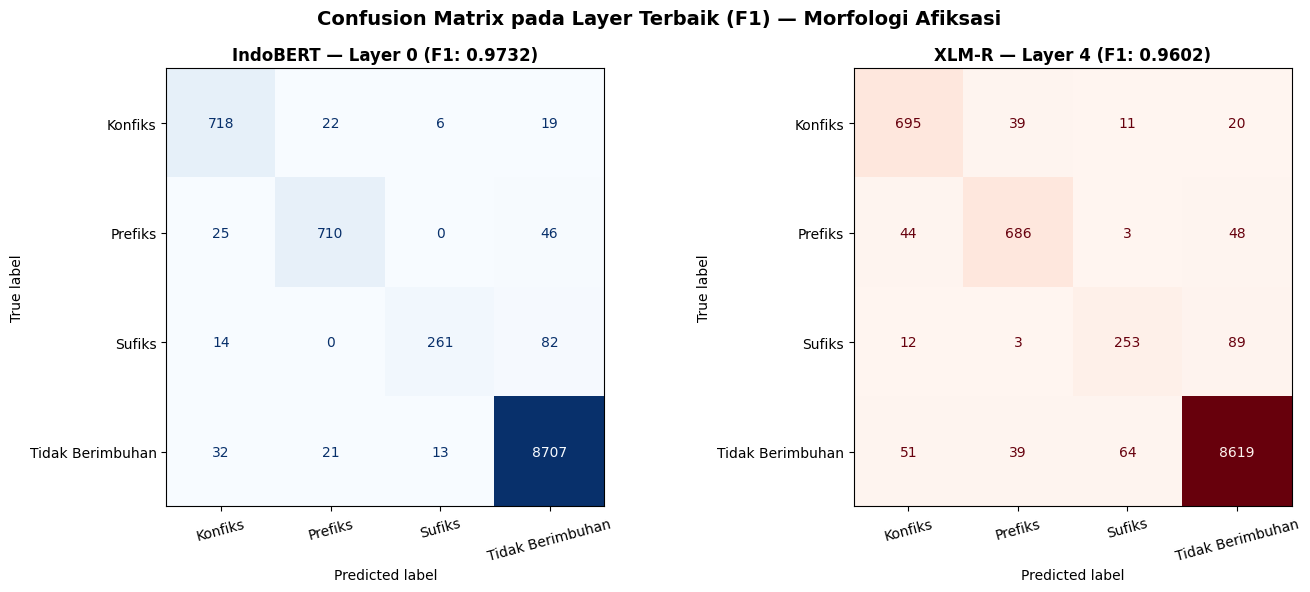


──────────────────────────────────────────────────────────────────────────────────
  RINGKASAN HASIL PROBING CLASSIFIER — MORFOLOGI AFIKSASI
──────────────────────────────────────────────────────────────────────────────────
                    ── IndoBERT ──                          ── XLM-R ──             
Layer        Acc    Prec     Rec      F1        Acc    Prec     Rec      F1
──────────────────────────────────────────────────────────────────────────────────
L0        0.9738  0.9735  0.9738  0.9732     0.9403  0.9376  0.9403  0.9352 ✦ best IB
L1        0.9668  0.9661  0.9668  0.9663     0.9396  0.9368  0.9396  0.9342
L2        0.9565  0.9559  0.9565  0.9559     0.9483  0.9467  0.9483  0.9468
L3        0.9505  0.9500  0.9505  0.9500     0.9564  0.9557  0.9564  0.9560
L4        0.9528  0.9520  0.9528  0.9522     0.9604  0.9601  0.9604  0.9602 ✦ best XLM
L5        0.9493  0.9486  0.9493  0.9488     0.9551  0.9535  0.9551  0.9534
L6        0.9457  0.9440  0.9457  0.9434     0.9506  0

In [12]:
# ==========================================================
# TAHAP 6: Training Probing Classifier & Visualisasi 
# ==========================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

# ── Definisi Probing Classifier ───────────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


def train_probe(X_train, y_train, X_eval, y_eval,
                hidden_size=768, num_classes=4,
                epochs=10, lr=1e-3, batch_size=64,
                return_preds=False):
    """Melatih probing classifier untuk satu layer. Return (acc, f1, precision, recall) atau +y_pred."""
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_ev = torch.tensor(X_eval,  dtype=torch.float32)
    y_ev = torch.tensor(y_eval,  dtype=torch.long)

    loader    = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=batch_size, shuffle=True)
    probe     = LinearProbe(hidden_size, num_classes).to(device)
    optimizer = optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        probe.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(probe(X_b), y_b).backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        y_pred = probe(X_ev.to(device)).argmax(dim=1).cpu().numpy()

    y_np  = y_ev.numpy()
    acc   = accuracy_score(y_np, y_pred)
    f1    = f1_score(y_np, y_pred, average='weighted')
    prec  = precision_score(y_np, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_np, y_pred, average='weighted', zero_division=0)

    if return_preds:
        return acc, f1, prec, rec, y_pred
    return acc, f1, prec, rec


# ── Training per Layer ────────────────────────────────────────────────────
results = {
    'indobert': {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []},
    'xlmr'    : {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []}
}

print("\n" + "=" * 85)
print("TRAINING PROBING CLASSIFIER PER LAYER — MORFOLOGI AFIKSASI")
print("=" * 85)
print(f"{'Layer':<7} {'IB Acc':>7} {'IB P':>7} {'IB R':>7} {'IB F1':>7} │ "
      f"{'XLM Acc':>7} {'XLM P':>7} {'XLM R':>7} {'XLM F1':>7}")
print("-" * 85)

for layer_idx in range(NUM_LAYERS):
    acc_i, f1_i, prec_i, rec_i, pred_i = train_probe(
        X_train_indobert[:, layer_idx, :], y_train,
        X_dev_indobert[:,   layer_idx, :], y_dev,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        return_preds=True
    )
    acc_x, f1_x, prec_x, rec_x, pred_x = train_probe(
        X_train_xlmr[:, layer_idx, :], y_train,
        X_dev_xlmr[:,   layer_idx, :], y_dev,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        return_preds=True
    )

    for key, vals in [
        ('indobert', (acc_i, f1_i, prec_i, rec_i, pred_i)),
        ('xlmr',     (acc_x, f1_x, prec_x, rec_x, pred_x))
    ]:
        results[key]['acc'].append(vals[0])
        results[key]['f1'].append(vals[1])
        results[key]['precision'].append(vals[2])
        results[key]['recall'].append(vals[3])
        results[key]['y_pred'].append(vals[4])

    print(f"L{layer_idx:<6} {acc_i:>7.4f} {prec_i:>7.4f} {rec_i:>7.4f} {f1_i:>7.4f} │ "
          f"{acc_x:>7.4f} {prec_x:>7.4f} {rec_x:>7.4f} {f1_x:>7.4f}")

print("=" * 85)

# ── Indeks layer terbaik ──────────────────────────────────────────────────
best = {
    model: {m: int(np.argmax(results[model][m]))
            for m in ['acc', 'f1', 'precision', 'recall']}
    for model in ['indobert', 'xlmr']
}

# ── Visualisasi Line Plot (Acc, Precision, Recall, F1) ───────────────────
layer_ticks  = [f"L{i}" for i in range(NUM_LAYERS)]
metrics_plot = [
    ('acc',       'Accuracy'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('f1',        'Weighted F1'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Probing Classifier — Morfologi Afiksasi | IndoBERT vs XLM-R',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    b_i = best['indobert'][metric]
    b_x = best['xlmr'][metric]

    ax.plot(layer_ticks, results['indobert'][metric],
            marker='o', linewidth=2, label='IndoBERT', color='#2980b9')
    ax.plot(layer_ticks, results['xlmr'][metric],
            marker='s', linewidth=2, label='XLM-R',    color='#e74c3c')

    ax.scatter(b_i, results['indobert'][metric][b_i],
               s=150, zorder=5, color='#2980b9', edgecolors='black', linewidths=1.5,
               label=f'Best IndoBERT: L{b_i} ({results["indobert"][metric][b_i]:.4f})')
    ax.scatter(b_x, results['xlmr'][metric][b_x],
               s=150, zorder=5, color='#e74c3c', marker='s', edgecolors='black', linewidths=1.5,
               label=f'Best XLM-R: L{b_x} ({results["xlmr"][metric][b_x]:.4f})')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels(layer_ticks)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Confusion Matrix pada Layer Terbaik F1 ───────────────────────────────
CLASS_NAMES = list(label_encoder.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix pada Layer Terbaik (F1) — Morfologi Afiksasi',
             fontsize=14, fontweight='bold')

for ax, model_key, model_name, color in zip(
    axes,
    ['indobert', 'xlmr'],
    ['IndoBERT', 'XLM-R'],
    ['Blues', 'Reds']
):
    b = best[model_key]['f1']
    cm = confusion_matrix(y_dev, results[model_key]['y_pred'][b])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'{model_name} — Layer {b} '
                 f'(F1: {results[model_key]["f1"][b]:.4f})',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ── Tabel Ringkasan ───────────────────────────────────────────────────────
METRICS = [('acc', 'Acc'), ('precision', 'Prec'), ('recall', 'Rec'), ('f1', 'F1')]

# Tandai baris terbaik berdasarkan F1
best_ib_row  = best['indobert']['f1']
best_xlm_row = best['xlmr']['f1']

# Header
col_w = 8
sep   = "─" * (7 + (col_w + 1) * 4 + 3 + (col_w + 1) * 4)
header_metrics = "".join(f"{lbl:>{col_w}}" for _, lbl in METRICS)

print(f"\n{'─' * len(sep)}")
print(f"  RINGKASAN HASIL PROBING CLASSIFIER — MORFOLOGI AFIKSASI")
print(f"{'─' * len(sep)}")
print(f"{'':7}  {'── IndoBERT ──':^{(col_w+1)*4}}   {'── XLM-R ──':^{(col_w+1)*4}}")
print(f"{'Layer':<7} {header_metrics}   {header_metrics}")
print(f"{'─' * len(sep)}")

for i in range(NUM_LAYERS):
    ib_vals  = "".join(f"{results['indobert'][m][i]:>{col_w}.4f}" for m, _ in METRICS)
    xlm_vals = "".join(f"{results['xlmr'][m][i]:>{col_w}.4f}"     for m, _ in METRICS)
    tag = " ✦ best IB"  if i == best_ib_row  else \
          " ✦ best XLM" if i == best_xlm_row else ""
    print(f"L{i:<6} {ib_vals}   {xlm_vals}{tag}")

print(f"{'─' * len(sep)}")

### 7. Analisis Geometris: Center Kernel Alignment (CKA) - Similarity

CKA mengukur kemiripan representasi antar layer / antar model.
<br>Nilai 1.0 = identik | Nilai 0.0 = sama sekali berbeda

Menghitung CKA internal IndoBERT...
Menghitung CKA internal XLM-R...
Menghitung CKA cross-model per layer...


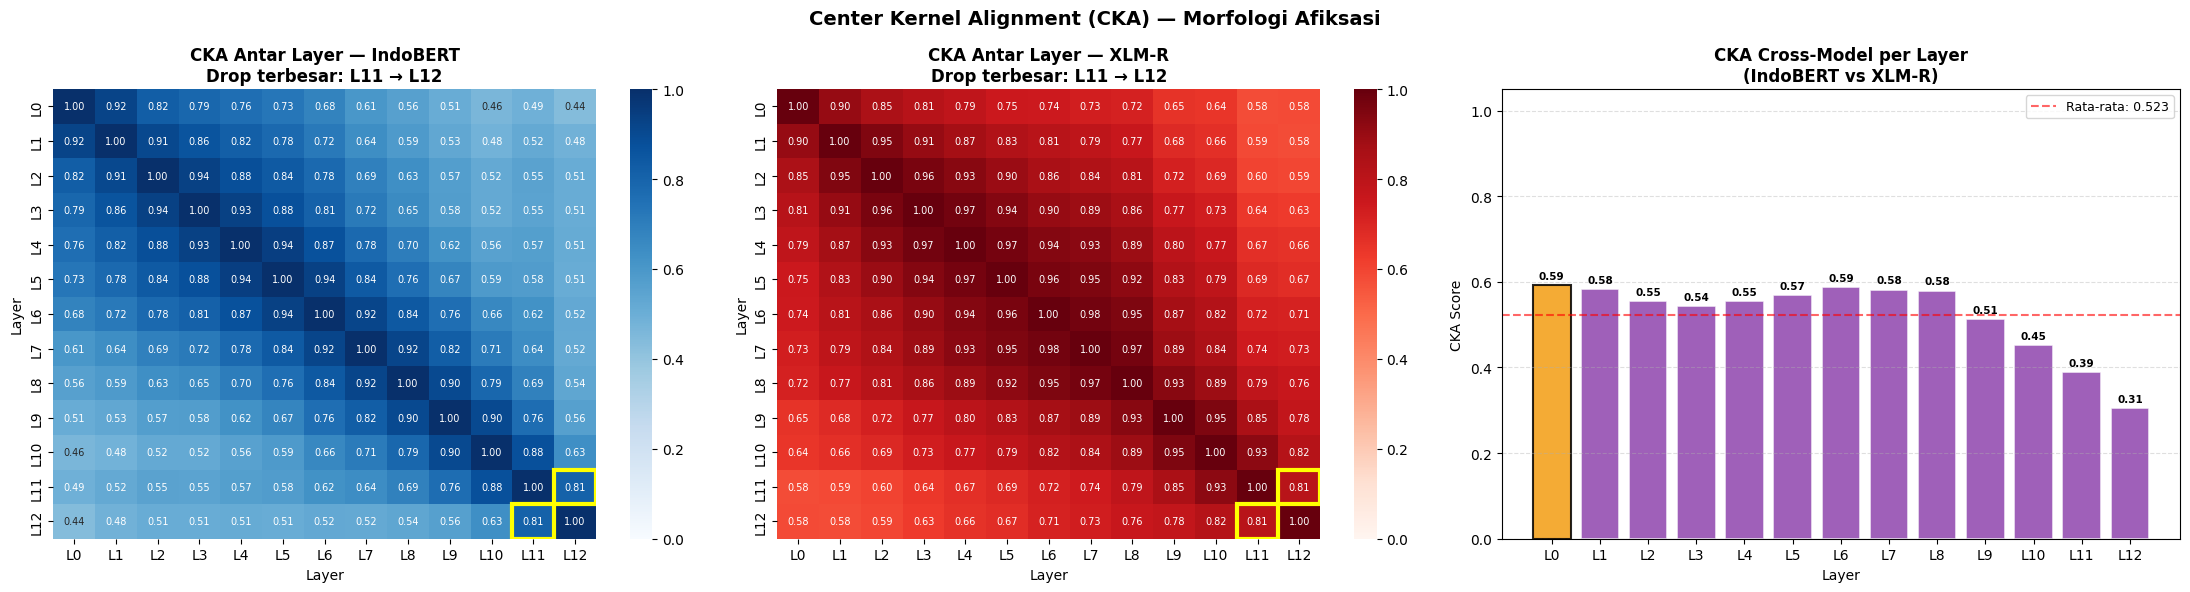

In [38]:
# ============================================================
# TAHAP 7: CENTER KERNEL ALIGNMENT (CKA)
# Visual clean + highlight sequential drop terbesar
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1) FUNGSI CKA
# ------------------------------------------------------------

def centering(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = centering(X @ X.T)
    L = centering(Y @ Y.T)
    num = np.sum(K * L)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(L * L))
    return float(num / den) if den > 0 else 0.0

def compute_cka_matrix(X_layers):
    n = X_layers.shape[1]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = linear_cka(X_layers[:, i, :], X_layers[:, j, :])
    return M


# ------------------------------------------------------------
# 2) HIGHLIGHT SEQUENTIAL DROP TERBESAR
# ------------------------------------------------------------

def highlight_sequential_max(ax, cka_matrix):
    """
    Highlight pasangan layer berurutan dengan drop terbesar.
    """
    n = cka_matrix.shape[0]

    seq_cka = np.array([cka_matrix[i, i+1] for i in range(n-1)])
    seq_drop = 1 - seq_cka

    best_idx = int(np.argmax(seq_drop))

    # kotak highlight (dua arah karena matriks simetris)
    rect1 = plt.Rectangle((best_idx+1, best_idx), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)
    rect2 = plt.Rectangle((best_idx, best_idx+1), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)

    ax.add_patch(rect1)
    ax.add_patch(rect2)

    return best_idx, seq_cka, seq_drop


# ------------------------------------------------------------
# 3) SAMPLING DATA
# ------------------------------------------------------------

layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]

MAX_CKA = 1000
idx_cka = np.random.choice(
    len(X_test_indobert),
    size=min(MAX_CKA, len(X_test_indobert)),
    replace=False
)

X_cka_ib  = X_test_indobert[idx_cka]
X_cka_xlm = X_test_xlmr[idx_cka]


# ------------------------------------------------------------
# 4) HITUNG CKA
# ------------------------------------------------------------

print("Menghitung CKA internal IndoBERT...")
cka_ib = compute_cka_matrix(X_cka_ib)

print("Menghitung CKA internal XLM-R...")
cka_xlm = compute_cka_matrix(X_cka_xlm)

print("Menghitung CKA cross-model per layer...")
cka_cross = np.array([
    linear_cka(X_cka_ib[:, i, :], X_cka_xlm[:, i, :])
    for i in range(NUM_LAYERS)
])


# ------------------------------------------------------------
# 5) VISUALISASI
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Center Kernel Alignment (CKA) — Morfologi Afiksasi',
             fontsize=14, fontweight='bold')

# ── Heatmap IndoBERT ────────────────────────────────────────
sns.heatmap(
    cka_ib,
    ax=axes[0],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_ib_idx, seq_cka_ib, seq_drop_ib = highlight_sequential_max(axes[0], cka_ib)

axes[0].set_title(
    f'CKA Antar Layer — IndoBERT\nDrop terbesar: L{best_ib_idx} → L{best_ib_idx+1}',
    fontweight='bold'
)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')


# ── Heatmap XLM-R ───────────────────────────────────────────
sns.heatmap(
    cka_xlm,
    ax=axes[1],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_xlm_idx, seq_cka_xlm, seq_drop_xlm = highlight_sequential_max(axes[1], cka_xlm)

axes[1].set_title(
    f'CKA Antar Layer — XLM-R\nDrop terbesar: L{best_xlm_idx} → L{best_xlm_idx+1}',
    fontweight='bold'
)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')


# ── Cross-model Bar Chart ───────────────────────────────────
bars = axes[2].bar(
    layer_ticks,
    cka_cross,
    color='#8e44ad',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

best_cross = int(np.argmax(cka_cross))

bars[best_cross].set_color('#f39c12')
bars[best_cross].set_edgecolor('black')
bars[best_cross].set_linewidth(1.5)

axes[2].set_title('CKA Cross-Model per Layer\n(IndoBERT vs XLM-R)',
                  fontweight='bold')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('CKA Score')
axes[2].set_ylim(0, 1.05)

axes[2].axhline(
    y=np.mean(cka_cross),
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Rata-rata: {np.mean(cka_cross):.3f}'
)

axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

for i, val in enumerate(cka_cross):
    axes[2].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()


### 8. Analisis Geometris: UMAP & Clustering per Layer

Memproses IndoBERT...


UMAP+Cluster IndoBERT:   0%|          | 0/13 [00:00<?, ?it/s]d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP+Cluster IndoBERT:   8%|▊         | 1/13 [00:01<00:19,  1.62s/it]d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP+Cluster IndoBERT:  15%|█▌        | 2/13 [00:03<00:17,  1.58s/it]d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP+Cluster IndoBERT:  23%|██

Memproses XLM-R...


UMAP+Cluster XLM-R:   0%|          | 0/13 [00:00<?, ?it/s]d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP+Cluster XLM-R:   8%|▊         | 1/13 [00:01<00:20,  1.73s/it]d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP+Cluster XLM-R:  15%|█▌        | 2/13 [00:03<00:19,  1.78s/it]d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP+Cluster XLM-R:  23%|██▎       | 3/


Layer terbaik IndoBERT : L12  (ARI=-0.0044, Sil=-0.0474, DBI=10.6435)
Layer terbaik XLM-R   : L0  (ARI=-0.0026, Sil=-0.0898, DBI=37.8270)


C:\Users\User\AppData\Local\Temp\ipykernel_31368\1769252634.py:122: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


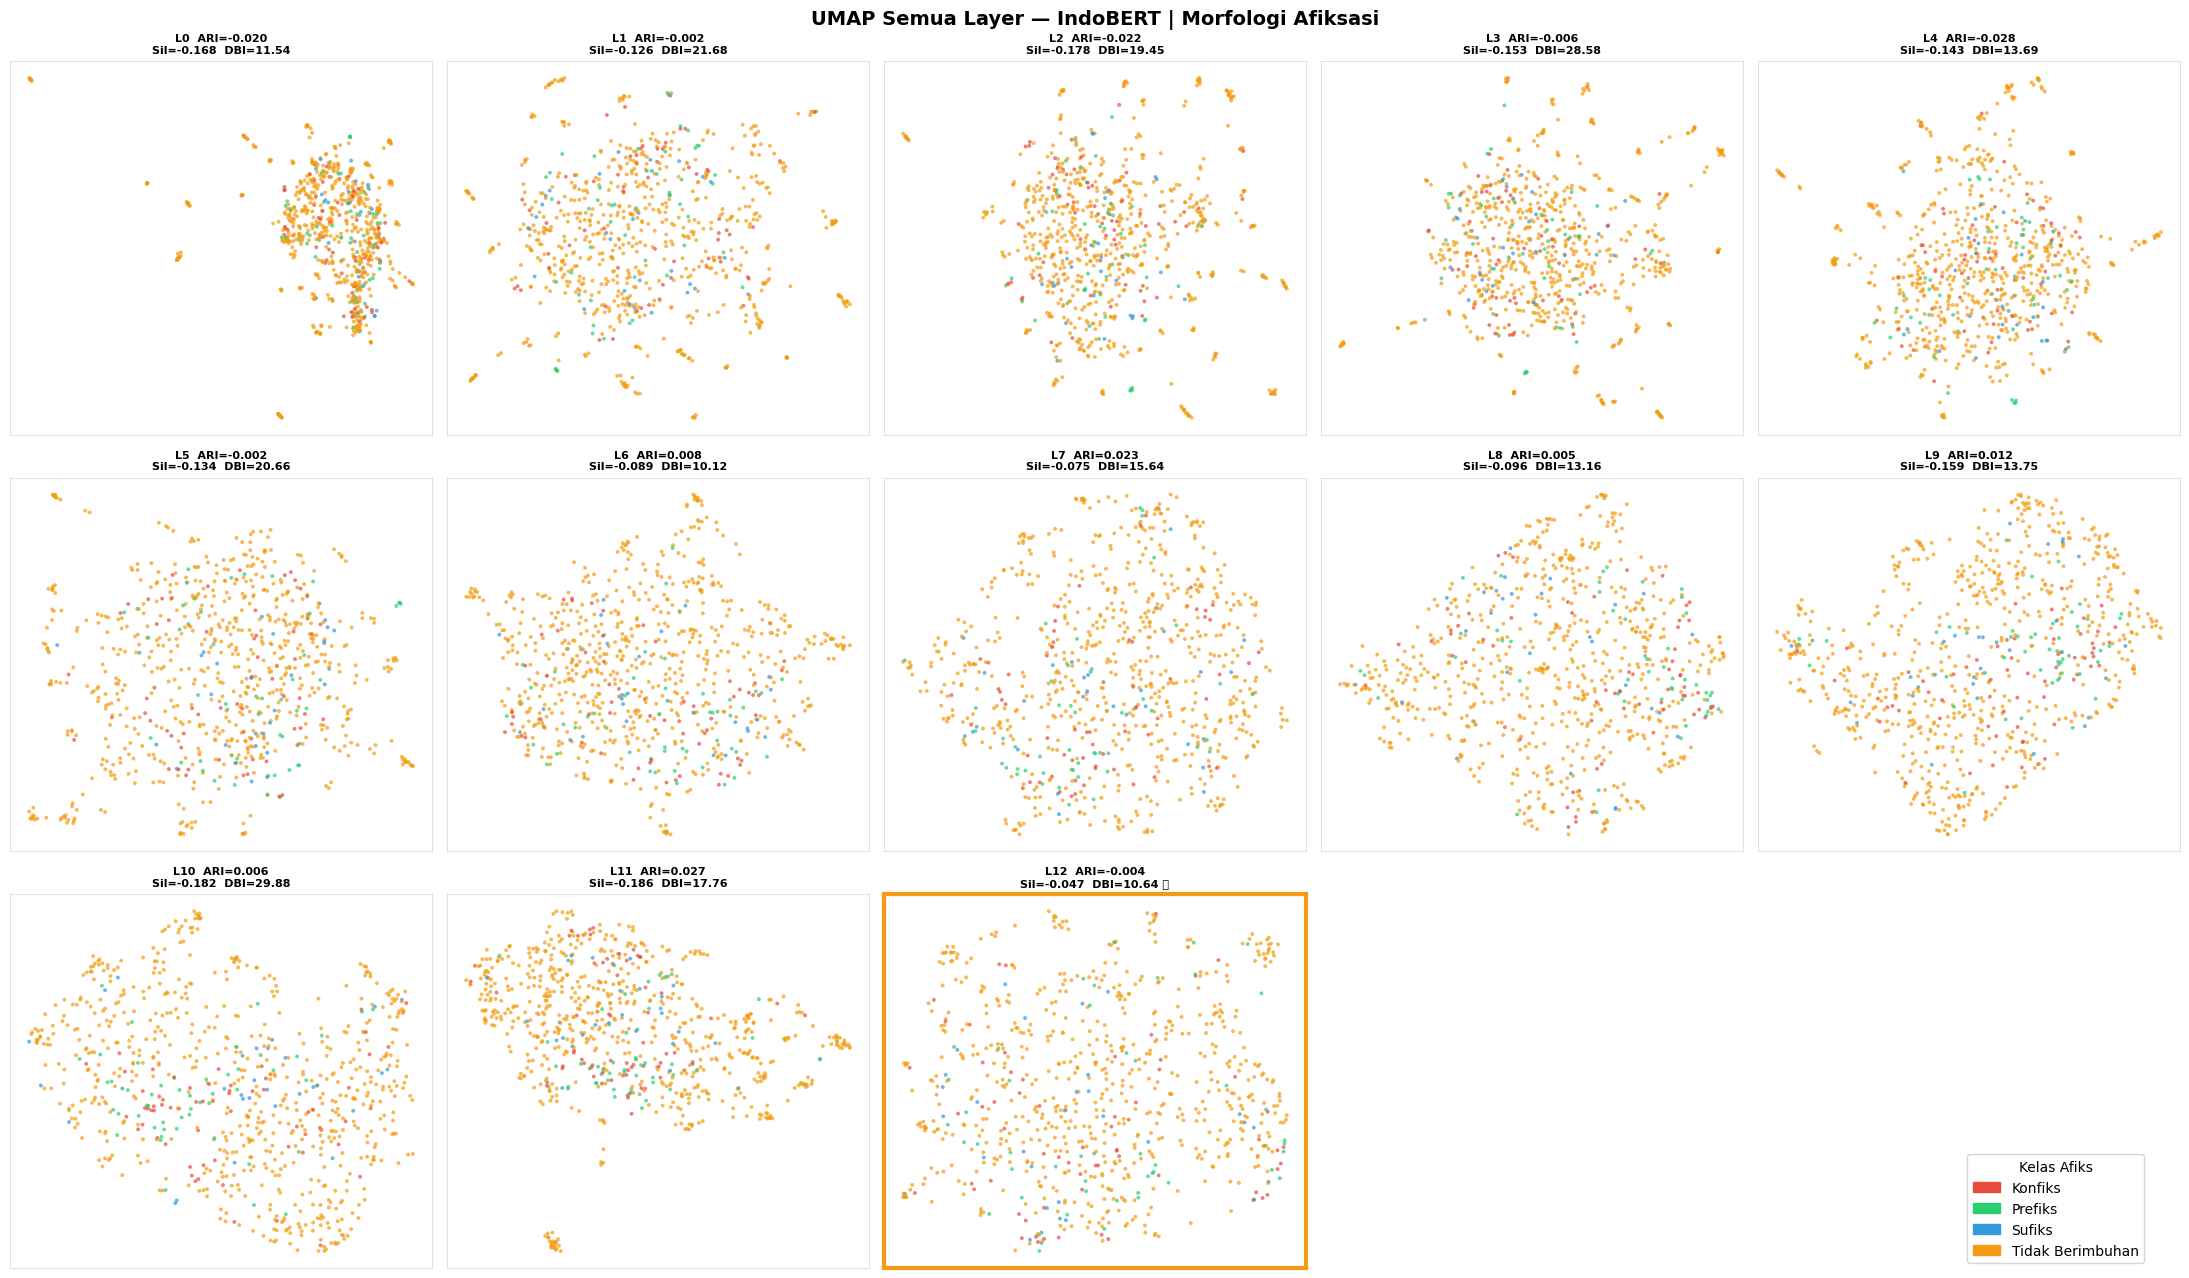

C:\Users\User\AppData\Local\Temp\ipykernel_31368\1769252634.py:157: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


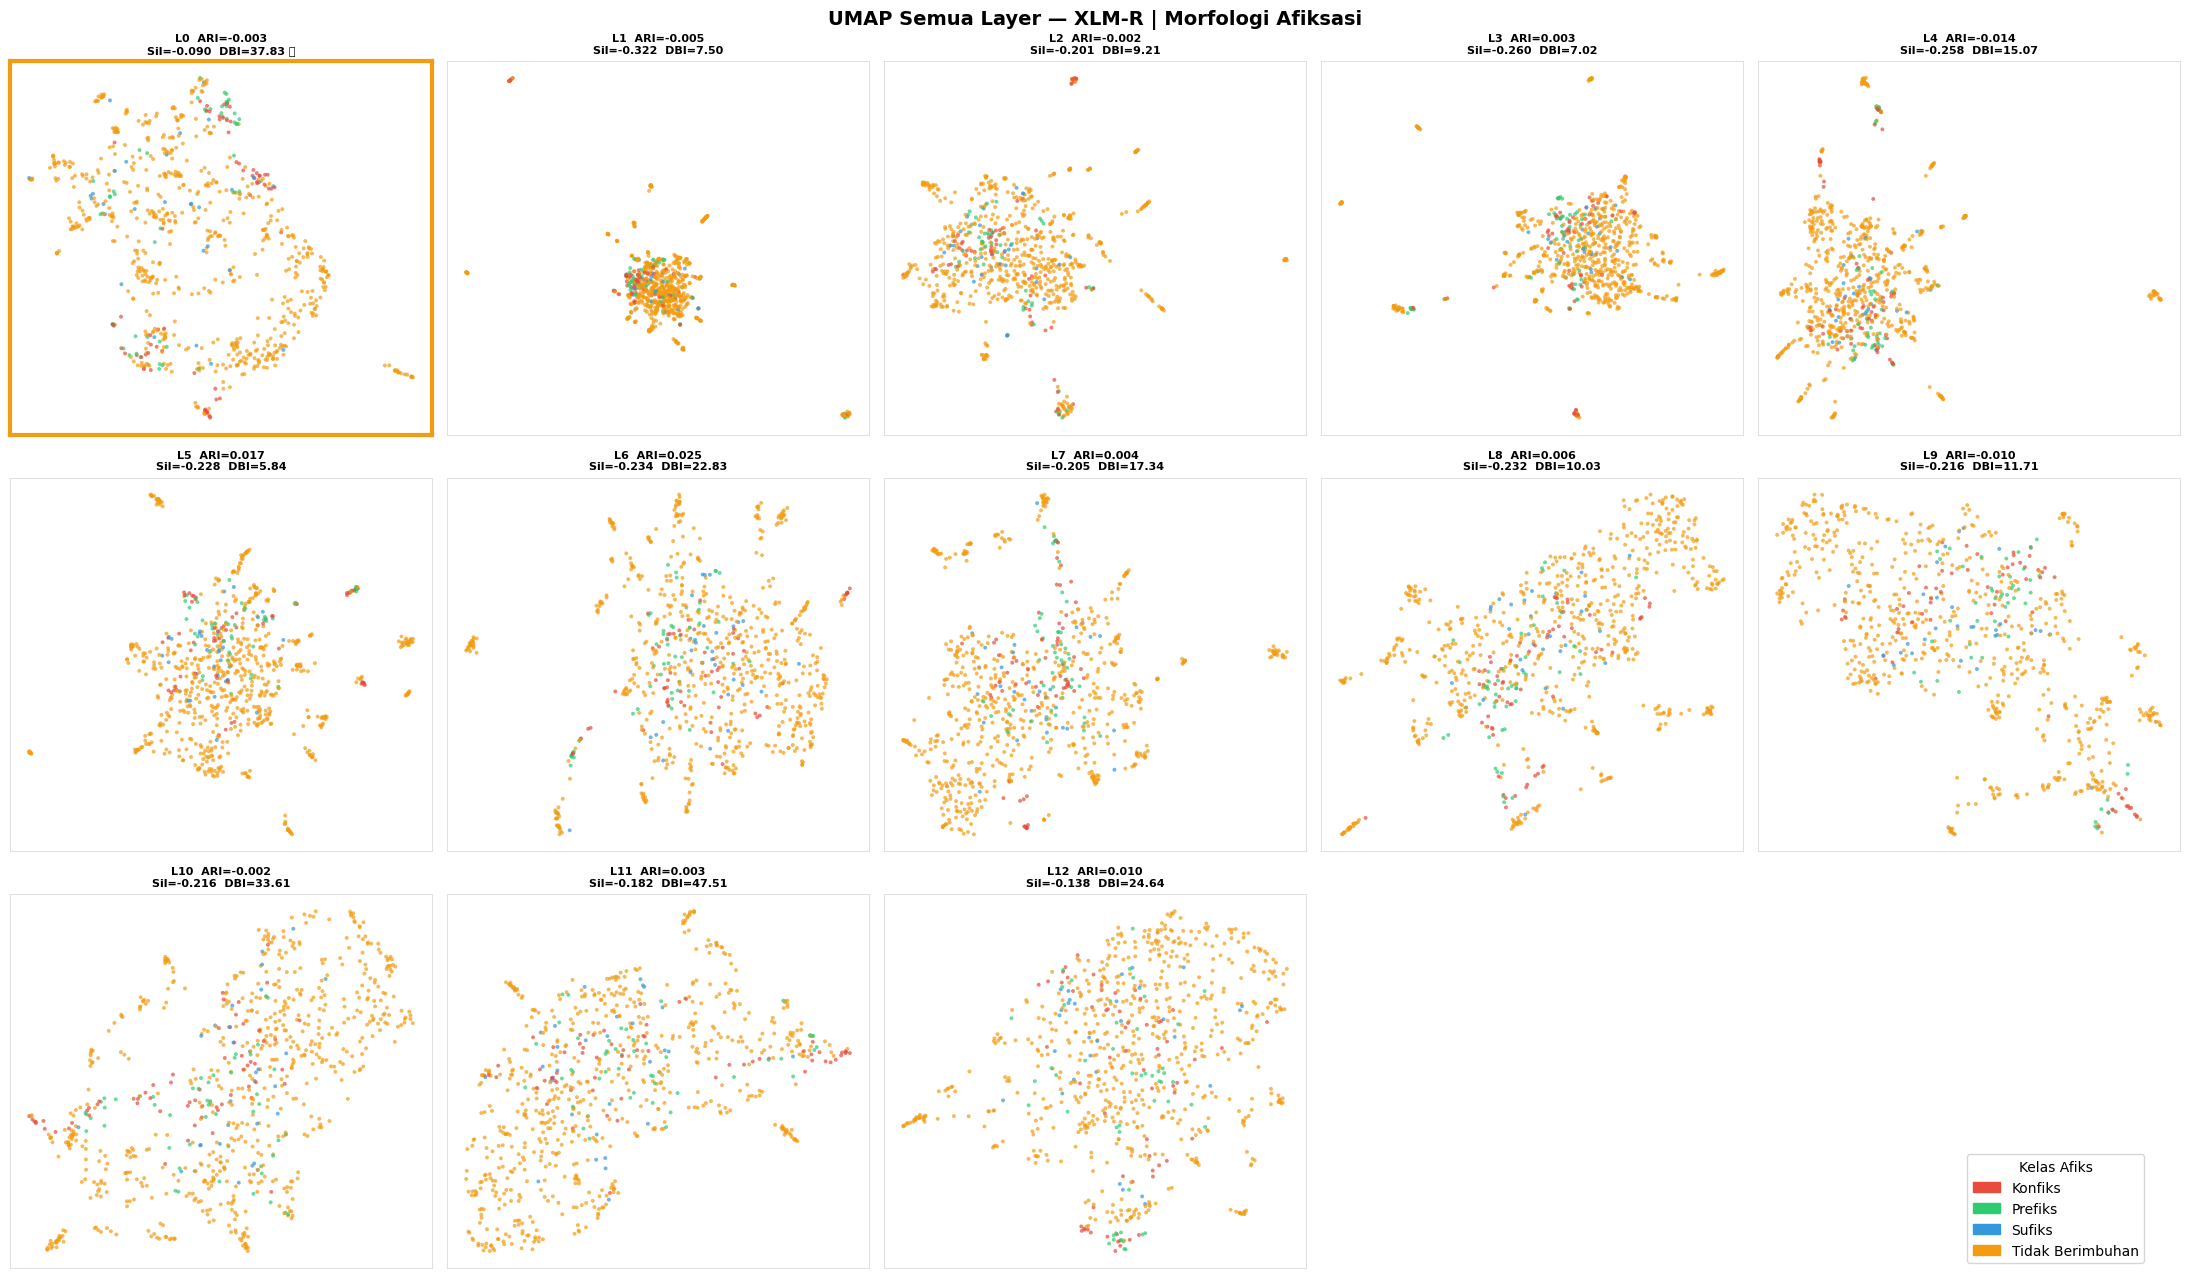

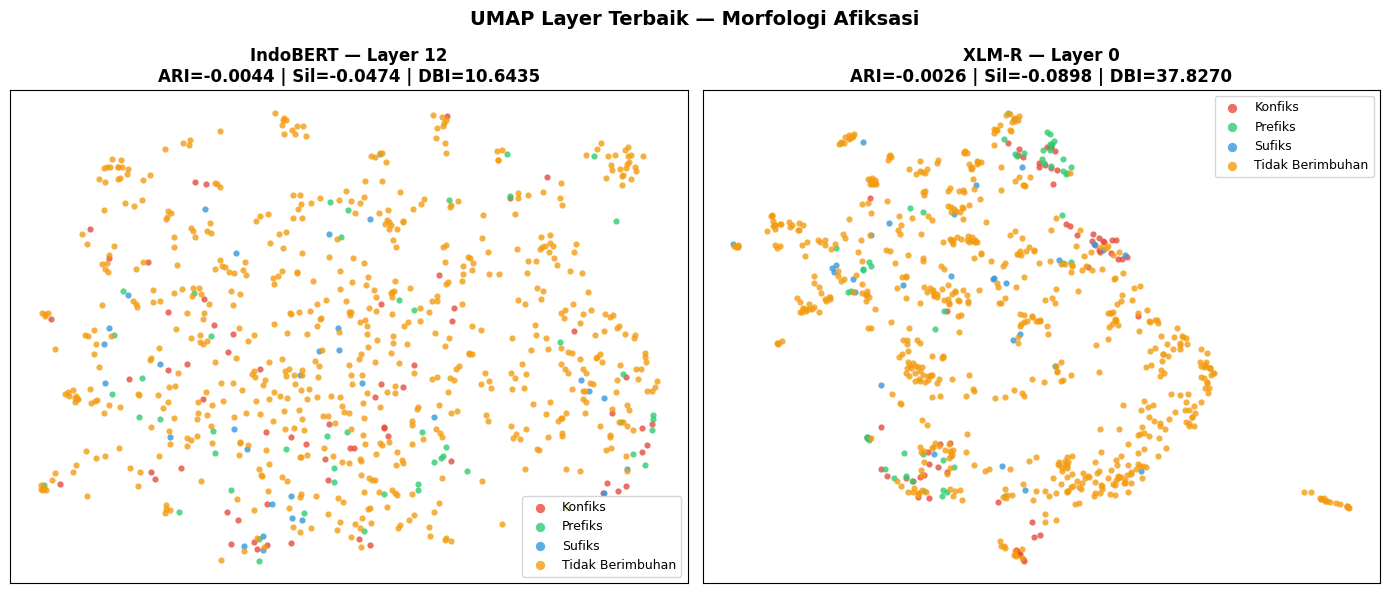

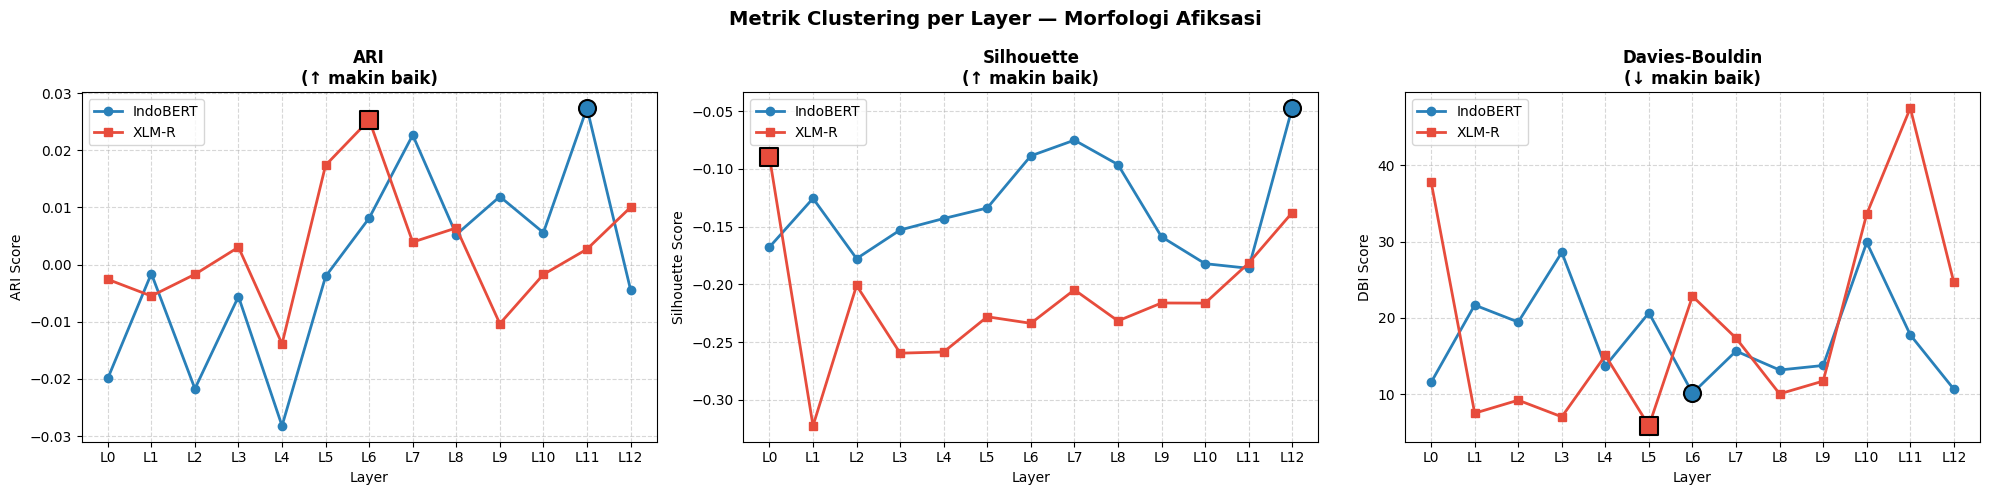


=== RINGKASAN CLUSTERING PER LAYER (UMAP 2D) ===
Layer     IB ARI   IB Sil   IB DBI   XLM ARI   XLM Sil   XLM DBI
---------------------------------------------------------------
L0       -0.0199  -0.1677  11.5371   -0.0026   -0.0898   37.8270 ← best XLM
L1       -0.0016  -0.1256  21.6770   -0.0055   -0.3224    7.5008
L2       -0.0217  -0.1777  19.4451   -0.0017   -0.2010    9.2053
L3       -0.0056  -0.1530  28.5779    0.0031   -0.2595    7.0229
L4       -0.0282  -0.1430  13.6928   -0.0139   -0.2585   15.0720
L5       -0.0021  -0.1339  20.6558    0.0174   -0.2280    5.8414
L6        0.0081  -0.0888  10.1218    0.0253   -0.2337   22.8319
L7        0.0227  -0.0752  15.6430    0.0039   -0.2047   17.3385
L8        0.0053  -0.0963  13.1613    0.0064   -0.2316   10.0324
L9        0.0119  -0.1589  13.7541   -0.0103   -0.2161   11.7107
L10       0.0056  -0.1821  29.8801   -0.0017   -0.2162   33.6133
L11       0.0274  -0.1861  17.7647    0.0027   -0.1816   47.5077
L12      -0.0044  -0.0474  10.

In [37]:
# ============================================================
# TAHAP 6 (REVISI): UMAP & CLUSTERING YANG LEBIH BAIK
# ============================================================

import umap.umap_ as umap
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

MAX_VIZ = 800
idx_viz = np.random.choice(len(X_test_indobert),
                            size=min(MAX_VIZ, len(X_test_indobert)),
                            replace=False)

X_viz_ib  = X_test_indobert[idx_viz]
X_viz_xlm = X_test_xlmr[idx_viz]
y_viz     = y_test[idx_viz]
y_colors  = [CLASS_COLORS[yi] for yi in y_viz]

CLASS_NAMES  = list(label_encoder.classes_)
CLASS_COLORS = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
patches      = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
                for i in range(NUM_CLASSES)]


def run_umap_clustering_v2(X_layers, y_true, desc=""):
    """
    Perbaikan:
    - UMAP dulu ke 2D
    - KMeans cluster di ruang 2D (bukan 768-dim)
    - Hitung ARI & Silhouette di ruang 2D
    - Hitung Davies-Bouldin Index (DBI) — makin kecil makin baik
    """
    umap_2d    = []
    ari_scores = []
    sil_scores = []
    dbi_scores = []

    for layer_idx in tqdm(range(NUM_LAYERS), desc=f"UMAP+Cluster {desc}"):
        X_layer = X_layers[:, layer_idx, :]  # (N, 768)

        # Step 1: Normalisasi sebelum UMAP
        scaler  = StandardScaler()
        X_scaled = scaler.fit_transform(X_layer)

        # Step 2: UMAP reduksi ke 2D
        reducer = umap.UMAP(n_components=2, random_state=42,
                            n_neighbors=15, min_dist=0.1)
        X_2d    = reducer.fit_transform(X_scaled)
        umap_2d.append(X_2d)

        # Step 3: KMeans di ruang 2D
        kmeans    = KMeans(n_clusters=NUM_CLASSES, random_state=42, n_init=10)
        y_cluster = kmeans.fit_predict(X_2d)

        # Step 4: Hitung metrik di ruang 2D
        ari = adjusted_rand_score(y_true, y_cluster)
        sil = silhouette_score(X_2d, y_true)   # pakai label asli
        dbi = davies_bouldin_score(X_2d, y_true)

        ari_scores.append(ari)
        sil_scores.append(sil)
        dbi_scores.append(dbi)

    return umap_2d, ari_scores, sil_scores, dbi_scores


# ── Jalankan ─────────────────────────────────────────────────────────────
print("Memproses IndoBERT...")
umap_ib,  ari_ib,  sil_ib,  dbi_ib  = run_umap_clustering_v2(
    X_viz_ib,  y_viz, "IndoBERT")

print("Memproses XLM-R...")
umap_xlm, ari_xlm, sil_xlm, dbi_xlm = run_umap_clustering_v2(
    X_viz_xlm, y_viz, "XLM-R")

# Layer terbaik: Silhouette tertinggi (makin tinggi makin baik)
best_layer_ib  = int(np.argmax(sil_ib))
best_layer_xlm = int(np.argmax(sil_xlm))

print(f"\nLayer terbaik IndoBERT : L{best_layer_ib}  "
      f"(ARI={ari_ib[best_layer_ib]:.4f}, "
      f"Sil={sil_ib[best_layer_ib]:.4f}, "
      f"DBI={dbi_ib[best_layer_ib]:.4f})")
print(f"Layer terbaik XLM-R   : L{best_layer_xlm}  "
      f"(ARI={ari_xlm[best_layer_xlm]:.4f}, "
      f"Sil={sil_xlm[best_layer_xlm]:.4f}, "
      f"DBI={dbi_xlm[best_layer_xlm]:.4f})")


# ── Plot A: Grid UMAP semua layer — IndoBERT ─────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
fig.suptitle('UMAP Semua Layer — IndoBERT | Morfologi Afiksasi',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i in range(NUM_LAYERS):
    ax   = axes_flat[i]
    X_2d = umap_ib[i]

    ax.scatter(X_2d[:, 0], X_2d[:, 1],
               c=y_colors, s=8, alpha=0.7, linewidths=0)

    border_color = '#f39c12' if i == best_layer_ib else 'lightgray'
    border_width = 3         if i == best_layer_ib else 0.5
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(border_width)

    title_tag = " ⭐" if i == best_layer_ib else ""
    ax.set_title(
        f"L{i}  ARI={ari_ib[i]:.3f}\n"
        f"Sil={sil_ib[i]:.3f}  DBI={dbi_ib[i]:.2f}{title_tag}",
        fontsize=8, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

for idx in range(NUM_LAYERS, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.legend(handles=patches, loc='lower right',
           bbox_to_anchor=(0.98, 0.01), fontsize=10, title='Kelas Afiks')
plt.tight_layout()
plt.show()


# ── Plot B: Grid UMAP semua layer — XLM-R ────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
fig.suptitle('UMAP Semua Layer — XLM-R | Morfologi Afiksasi',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i in range(NUM_LAYERS):
    ax   = axes_flat[i]
    X_2d = umap_xlm[i]

    ax.scatter(X_2d[:, 0], X_2d[:, 1],
               c=y_colors, s=8, alpha=0.7, linewidths=0)

    border_color = '#f39c12' if i == best_layer_xlm else 'lightgray'
    border_width = 3         if i == best_layer_xlm else 0.5
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(border_width)

    title_tag = " ⭐" if i == best_layer_xlm else ""
    ax.set_title(
        f"L{i}  ARI={ari_xlm[i]:.3f}\n"
        f"Sil={sil_xlm[i]:.3f}  DBI={dbi_xlm[i]:.2f}{title_tag}",
        fontsize=8, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

for idx in range(NUM_LAYERS, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.legend(handles=patches, loc='lower right',
           bbox_to_anchor=(0.98, 0.01), fontsize=10, title='Kelas Afiks')
plt.tight_layout()
plt.show()


# ── Plot C: Highlight Layer Terbaik ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('UMAP Layer Terbaik — Morfologi Afiksasi',
             fontsize=14, fontweight='bold')

for ax, X_2d, best_l, model_name, ari_s, sil_s, dbi_s in zip(
    axes,
    [umap_ib[best_layer_ib], umap_xlm[best_layer_xlm]],
    [best_layer_ib, best_layer_xlm],
    ['IndoBERT', 'XLM-R'],
    [ari_ib[best_layer_ib],  ari_xlm[best_layer_xlm]],
    [sil_ib[best_layer_ib],  sil_xlm[best_layer_xlm]],
    [dbi_ib[best_layer_ib],  dbi_xlm[best_layer_xlm]]
):
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_viz == cls_idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=CLASS_COLORS[cls_idx], s=20, alpha=0.8,
                   linewidths=0, label=cls_name)

    ax.set_title(
        f'{model_name} — Layer {best_l}\n'
        f'ARI={ari_s:.4f} | Sil={sil_s:.4f} | DBI={dbi_s:.4f}',
        fontweight='bold')
    ax.legend(fontsize=9, markerscale=1.5)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


# ── Plot D: Kurva 3 Metrik per Layer ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Metrik Clustering per Layer — Morfologi Afiksasi',
             fontsize=14, fontweight='bold')

metrics_cfg = [
    ('ARI',             ari_ib,  ari_xlm,  'ARI Score',         '↑ makin baik'),
    ('Silhouette',      sil_ib,  sil_xlm,  'Silhouette Score',  '↑ makin baik'),
    ('Davies-Bouldin',  dbi_ib,  dbi_xlm,  'DBI Score',         '↓ makin baik'),
]

for ax, (name, s_ib, s_xlm, ylabel, note) in zip(axes, metrics_cfg):
    ax.plot(layer_ticks, s_ib,  marker='o', linewidth=2,
            label='IndoBERT', color='#2980b9')
    ax.plot(layer_ticks, s_xlm, marker='s', linewidth=2,
            label='XLM-R',   color='#e74c3c')

    best_ib  = int(np.argmin(s_ib)  if name == 'Davies-Bouldin' else np.argmax(s_ib))
    best_xlm = int(np.argmin(s_xlm) if name == 'Davies-Bouldin' else np.argmax(s_xlm))

    ax.scatter(best_ib,  s_ib[best_ib],
               s=150, zorder=5, color='#2980b9',
               edgecolors='black', linewidths=1.5)
    ax.scatter(best_xlm, s_xlm[best_xlm],
               s=150, zorder=5, color='#e74c3c', marker='s',
               edgecolors='black', linewidths=1.5)

    ax.set_title(f'{name}\n({note})', fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels(layer_ticks)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Tabel ringkasan
print("\n=== RINGKASAN CLUSTERING PER LAYER (UMAP 2D) ===")
print(f"{'Layer':<7} {'IB ARI':>8} {'IB Sil':>8} {'IB DBI':>8} "
      f"{'XLM ARI':>9} {'XLM Sil':>9} {'XLM DBI':>9}")
print("-" * 63)
for i in range(NUM_LAYERS):
    tag = " ← best IB"  if i == best_layer_ib  else \
          " ← best XLM" if i == best_layer_xlm else ""
    print(f"L{i:<6} {ari_ib[i]:>8.4f} {sil_ib[i]:>8.4f} {dbi_ib[i]:>8.4f} "
          f"{ari_xlm[i]:>9.4f} {sil_xlm[i]:>9.4f} {dbi_xlm[i]:>9.4f}{tag}")

## B. POS Tagging (Syntactic)

## C. Relasi Sintaksis (Syntactic)

## D. Negasi (Semantic)